# Vector-Q Transformer SAC — offline inference demo

This notebook loads the trained racing policy from a GitHub-hosted checkpoint, feeds it a handful of real observation windows sampled from the stratified replay buffer, and visualises what the policy + per-channel critic predict.

No Assetto Corsa required — everything is read from static files in the repo.

**Artefacts fetched from GitHub:**
- `demo/inference_ckpt.pt` — stripped checkpoint (policy + critic weights, ~26 MB)
- `demo/sample_data.npz` — 216 observation windows sampled across the 6 stratified sub-buffers (~2 MB)

Everything else — the `TransformerEncoder`, `PolicyHead`, `TwinQHead` classes — is inlined below, so the notebook is fully self-contained and runs on Colab with a stock `torch` / `numpy` / `matplotlib`.

## Watch the full lap

The cell below embeds the full-lap Monza demo directly — run it to play the video inline. Or open it on YouTube: https://youtu.be/ZNJG0orcfXg

In [57]:
from IPython.display import HTML

GIF_URL   = ('https://raw.githubusercontent.com/virtual457/'
             'transformer-based-autonomous-racing-agent/main/'
             'figures/demo_preview.gif')
VIDEO_URL = 'https://youtu.be/ZNJG0orcfXg'

HTML(f'''
<div align="center">
  <a href="{VIDEO_URL}" target="_blank">
    <img src="{GIF_URL}" alt="Vector-Q Transformer SAC full-lap on Monza" width="720"/>
  </a>
  <br/>
  <em>Click the clip to watch the full video on YouTube.</em>
</div>
''')

## 1. Install (Colab) and imports

In [58]:
# Uncomment on a fresh Colab runtime.
# !pip install -q torch numpy matplotlib

import io, os, json, urllib.request
import numpy as np
import torch
import torch.nn as nn
from torch.distributions import Normal
import matplotlib.pyplot as plt

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('torch version:', torch.__version__, '| device:', DEVICE)

torch version: 2.5.1+cu121 | device: cuda


## 2. Fetch checkpoint + sample data from GitHub

In [59]:
REPO = 'virtual457/transformer-based-autonomous-racing-agent'
BRANCH = 'main'
BASE = f'https://raw.githubusercontent.com/{REPO}/{BRANCH}/demo'

CKPT_URL = f'{BASE}/inference_ckpt.pt'
DATA_URL = f'{BASE}/sample_data.npz'

def fetch(url, path):
    if os.path.exists(path):
        print(f'exists  {path}')
        return
    print(f'fetching {url}')
    urllib.request.urlretrieve(url, path)
    print(f'wrote    {path}  ({os.path.getsize(path)/1e6:.1f} MB)')

fetch(CKPT_URL, 'inference_ckpt.pt')
fetch(DATA_URL, 'sample_data.npz')

exists  inference_ckpt.pt
exists  sample_data.npz


## 3. Network definitions (inlined from `gym/.../network.py`)

Three modules: `TransformerEncoder` (4 Pre-LN layers, 4 heads, `d_model=256`, 75-token window), `PolicyHead` (diagonal-Gaussian tanh-squashed), `TwinQHead` (two independent per-channel Q networks).

In [60]:
LOG_STD_MIN, LOG_STD_MAX = -20, 2
TANH_LOG_EPSILON = 1e-6

def _make_mlp(input_dim, output_dim, hidden_units):
    layers, in_dim = [], input_dim
    for h in hidden_units:
        lin = nn.Linear(in_dim, h)
        nn.init.xavier_uniform_(lin.weight); nn.init.zeros_(lin.bias)
        layers += [lin, nn.ReLU()]
        in_dim = h
    final = nn.Linear(in_dim, output_dim)
    nn.init.xavier_uniform_(final.weight); nn.init.zeros_(final.bias)
    layers.append(final)
    return nn.Sequential(*layers)

class TransformerEncoder(nn.Module):
    def __init__(self, token_dim=50, d_model=256, n_heads=4, n_layers=4,
                 ffn_dim=1024, window_size=75, dropout=0.0):
        super().__init__()
        self.input_proj = nn.Linear(token_dim, d_model)
        nn.init.xavier_uniform_(self.input_proj.weight); nn.init.zeros_(self.input_proj.bias)
        self.pos_embedding = nn.Embedding(window_size, d_model)
        layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=n_heads,
            dim_feedforward=ffn_dim, dropout=dropout, activation='relu',
            batch_first=True, norm_first=True)
        self.transformer = nn.TransformerEncoder(layer, num_layers=n_layers,
                                                 enable_nested_tensor=False)
    def forward(self, x):
        B, W, _ = x.shape
        pos = torch.arange(W, device=x.device).unsqueeze(0)
        x = self.input_proj(x) + self.pos_embedding(pos)
        x = self.transformer(x)
        return x.mean(dim=1)

class PolicyHead(nn.Module):
    def __init__(self, d_model=256, action_dim=3, hidden_units=None):
        super().__init__()
        if hidden_units is None: hidden_units = [256]
        self.net = _make_mlp(d_model, action_dim * 2, hidden_units)

class TwinQHead(nn.Module):
    def __init__(self, d_model=256, action_dim=3, reward_dim=3, hidden_units=None):
        super().__init__()
        if hidden_units is None: hidden_units = [256]
        self.q1_net = _make_mlp(d_model + action_dim, reward_dim, hidden_units)
        self.q2_net = _make_mlp(d_model + action_dim, reward_dim, hidden_units)
    def forward(self, embedding, action):
        x = torch.cat([embedding, action], dim=-1)
        return self.q1_net(x), self.q2_net(x)

## 4. Load the checkpoint and rebuild the network

In [61]:
ckpt = torch.load('inference_ckpt.pt', map_location=DEVICE, weights_only=False)
cfg = ckpt['config']
print('config:')
for k in ('token_dim','window_size','d_model','n_heads','n_layers',
         'ffn_dim','action_dim'):
    print(f'  {k:<12} = {cfg[k]}')
print(f"  target_entropy = {cfg['target_entropy'].tolist()}")

policy_encoder = TransformerEncoder(
    token_dim=cfg['token_dim'], d_model=cfg['d_model'],
    n_heads=cfg['n_heads'],     n_layers=cfg['n_layers'],
    ffn_dim=cfg['ffn_dim'],     window_size=cfg['window_size']).to(DEVICE)
critic_encoder = TransformerEncoder(
    token_dim=cfg['token_dim'], d_model=cfg['d_model'],
    n_heads=cfg['n_heads'],     n_layers=cfg['n_layers'],
    ffn_dim=cfg['ffn_dim'],     window_size=cfg['window_size']).to(DEVICE)
policy_head = PolicyHead(d_model=cfg['d_model'], action_dim=cfg['action_dim'],
                         hidden_units=cfg['policy_hidden']).to(DEVICE)
twin_q      = TwinQHead(d_model=cfg['d_model'], action_dim=cfg['action_dim'],
                        reward_dim=cfg['action_dim'],
                        hidden_units=cfg['q_hidden']).to(DEVICE)

policy_encoder.load_state_dict(ckpt['policy_encoder'])
critic_encoder.load_state_dict(ckpt['critic_encoder'])
policy_head.load_state_dict(ckpt['policy_head'])
twin_q.load_state_dict(ckpt['twin_q'])
for m in (policy_encoder, critic_encoder, policy_head, twin_q): m.eval()

n = sum(p.numel() for m in (policy_encoder, critic_encoder, policy_head, twin_q)
                   for p in m.parameters())
print(f'\nloaded {n/1e6:.2f}M parameters')

config:
  token_dim    = 50
  window_size  = 75
  d_model      = 256
  n_heads      = 4
  n_layers     = 4
  ffn_dim      = 1024
  action_dim   = 3
  target_entropy = [-2.0, -3.0, -3.0]

loaded 6.58M parameters


## 5. Load the sample observation windows

216 windows = 36 per sub-buffer × 6 sub-buffers. Each window is 75 frames × 50-dim observation tokens — exactly what the model was trained on.

In [62]:
data = np.load('sample_data.npz', allow_pickle=True)
sample_obs  = data['obs']     # (N, 75, 50)
sample_act  = data['action']  # (N, 3)
sample_rew  = data['reward']  # (N, 3)
sample_tag  = data['tag']     # (N,) str — which sub-buffer each window came from
N = len(sample_obs)
print(f'N = {N} windows  |  obs shape = {sample_obs.shape}')

N = 216 windows  |  obs shape = (216, 75, 50)


## 6. Run inference

For every window:
- **Policy**: deterministic action = `tanh(mean)` + per-channel standard deviation.
- **Critic**: clipped double-Q vector `Q = min(Q1, Q2) ∈ R^3` at the policy's action.

In [63]:
x = torch.from_numpy(sample_obs).float().clamp(-3.0, 3.0).to(DEVICE)

with torch.no_grad():
    pol_emb = policy_encoder(x)
    out = policy_head.net(pol_emb)
    mean_raw, log_std = out.chunk(2, dim=-1)
    log_std = log_std.clamp(LOG_STD_MIN, LOG_STD_MAX)
    std = log_std.exp()
    action_det = torch.tanh(mean_raw)

    crit_emb = critic_encoder(x)
    q1, q2 = twin_q(crit_emb, action_det)
    q_vec  = torch.min(q1, q2).cpu().numpy()

action_det = action_det.cpu().numpy()
std        = std.cpu().numpy()

print(f'action means:   steer={action_det[:,0].mean():+.3f}'
      f'  throttle={action_det[:,1].mean():+.3f}'
      f'  brake={action_det[:,2].mean():+.3f}')
print(f'policy std:     steer={std[:,0].mean():.3f}'
      f'   throttle={std[:,1].mean():.3f}'
      f'   brake={std[:,2].mean():.3f}')
print(f'per-channel Q:  steer={q_vec[:,0].mean():.2f}'
      f'   throttle={q_vec[:,1].mean():.2f}'
      f'   brake={q_vec[:,2].mean():.2f}')

action means:   steer=+0.022  throttle=+0.881  brake=-0.709
policy std:     steer=0.273   throttle=0.528   brake=0.505
per-channel Q:  steer=39.55   throttle=57.18   brake=55.53


## 7. Visualise per-channel Q

Histogram of `min(Q1, Q2)` on each of the three critic heads at the policy's chosen action, one subplot per channel. Each channel should show a clear high-value mode (this sample is biased toward positive-reward frames), and the three heads should have distinct distributions — evidence that the decomposition is balanced rather than collapsed into a single scalar in disguise.

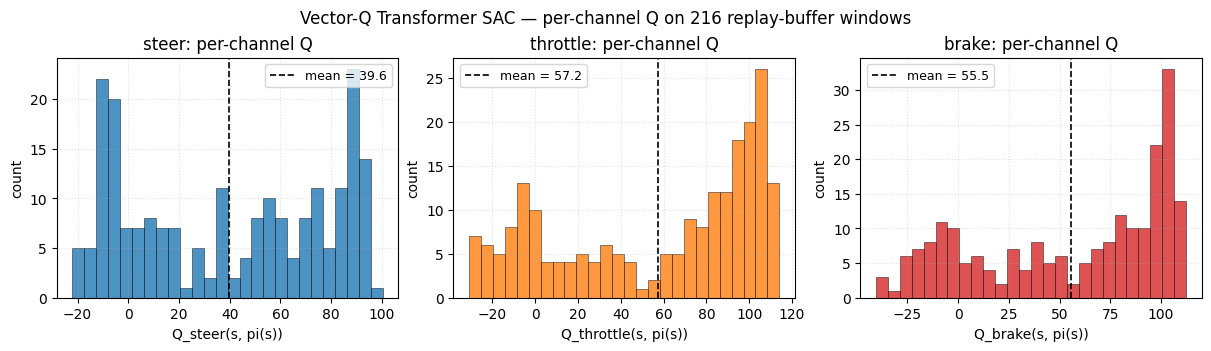

In [64]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4), constrained_layout=True)
names = ['steer', 'throttle', 'brake']
cols  = ['tab:blue', 'tab:orange', 'tab:red']

for i, (ax, name, c) in enumerate(zip(axes, names, cols)):
    ax.hist(q_vec[:, i], bins=26, color=c, alpha=0.8,
            edgecolor='black', linewidth=0.4)
    ax.axvline(q_vec[:, i].mean(), color='black', lw=1.2, ls='--',
               label=f'mean = {q_vec[:, i].mean():.1f}')
    ax.set_xlabel(f'Q_{name}(s, pi(s))')
    ax.set_ylabel('count')
    ax.set_title(f'{name}: per-channel Q')
    ax.legend(fontsize=9)
    ax.grid(True, ls=':', alpha=0.35)

fig.suptitle(f'Vector-Q Transformer SAC — per-channel Q on {N} replay-buffer windows',
             fontsize=12)
plt.show()

## 8. Inspect a single window

In [65]:
idx = 0
print(f'buffer tag:           {sample_tag[idx]}')
print(f'stored action:        {sample_act[idx].tolist()}')
print(f'stored per-ch reward: {sample_rew[idx].tolist()}')
print(f'policy predicted:     {action_det[idx].tolist()}')
print(f'policy std per chan:  {std[idx].tolist()}')
print(f'per-channel Q at pi:  {q_vec[idx].tolist()}')

buffer tag:           steer_pos
stored action:        [0.11525630205869675, 0.9934545755386353, -0.9948925971984863]
stored per-ch reward: [0.5596507787704468, 0.8855212926864624, 0.8868481516838074]
policy predicted:     [0.04086170718073845, 0.9863420128822327, -0.9936687350273132]
policy std per chan:  [0.13482610881328583, 0.5179603099822998, 0.5153506398200989]
per-channel Q at pi:  [74.57466125488281, 99.1540756225586, 98.01467895507812]


## 9. Track map — where the policy brakes vs. accelerates

Rather than compare against a human, we can just look at what the policy *actually did* during a full-lap evaluation on Monza. Every frame of the recorded lap has world position, speed, and the raw brake / throttle actions the policy applied. Colouring the trajectory by those channels lets us see — at a glance — whether the policy learned to **accelerate on the straights** and **brake before corners**.

In [66]:
# Fetch the recorded full-lap telemetry (~340 KB).
TRAJ_URL = f'{BASE}/lap_trajectory.npz'
fetch(TRAJ_URL, 'lap_trajectory.npz')

lap = np.load('lap_trajectory.npz')
lx, ly   = lap['x'], lap['y']
speed    = lap['speed']
throttle = lap['throttle']      # raw action in [-1, 1]; -1 = off, +1 = full
brake    = lap['brake']         # raw action in [-1, 1]; -1 = off, +1 = full

# Remap both to [0, 1] for cleaner colour scales.
throttle01 = np.clip((throttle + 1.0) * 0.5, 0.0, 1.0)
brake01    = np.clip((brake    + 1.0) * 0.5, 0.0, 1.0)

print(f'lap: {len(lx)} frames,  track length {lx.max() - lx.min():.0f} m x'
      f' {ly.max() - ly.min():.0f} m')
print(f'  speed:    mean={speed.mean():.1f} m/s   max={speed.max():.1f} m/s')
print(f'  frames with brake > 0.3:    {(brake01 > 0.3).mean() * 100:.1f}%')
print(f'  frames with throttle > 0.7: {(throttle01 > 0.7).mean() * 100:.1f}%')

exists  lap_trajectory.npz
lap: 17171 frames,  track length 2165 m x 1258 m
  speed:    mean=31.5 m/s   max=46.3 m/s
  frames with brake > 0.3:    14.4%
  frames with throttle > 0.7: 100.0%


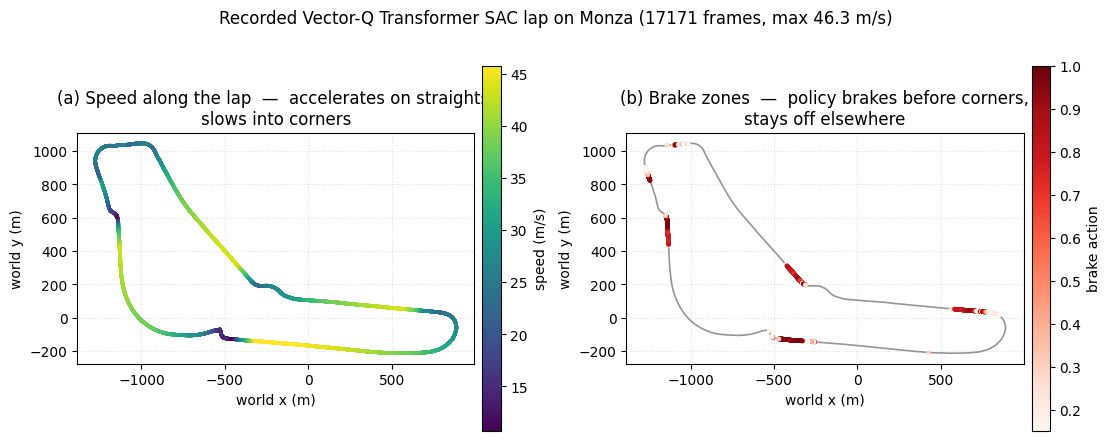

In [67]:
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize

def colored_line(ax, x, y, c, cmap, vmin, vmax, lw=2.6):
    pts  = np.column_stack([x, y]).reshape(-1, 1, 2)
    segs = np.concatenate([pts[:-1], pts[1:]], axis=1)
    lc   = LineCollection(segs, cmap=cmap, norm=Normalize(vmin, vmax),
                          linewidth=lw, capstyle='round')
    lc.set_array(c[:-1]); ax.add_collection(lc); return lc

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.6), constrained_layout=True)

# (a) Speed along the lap — yellow / green on the straights (fast) means
#     the policy is accelerating and holding speed; dark patches are slow
#     corner apexes.
lc_s = colored_line(ax1, lx, ly, speed, cmap='viridis',
                    vmin=float(np.percentile(speed, 2)),
                    vmax=float(np.percentile(speed, 98)))
ax1.autoscale_view(); ax1.set_aspect('equal')
ax1.set_title('(a) Speed along the lap  —  accelerates on straights,\n'
              'slows into corners')
ax1.set_xlabel('world x (m)'); ax1.set_ylabel('world y (m)')
fig.colorbar(lc_s, ax=ax1, fraction=0.046, pad=0.02).set_label('speed (m/s)')
ax1.grid(True, ls=':', alpha=0.35)

# (b) Brake zones — gray track + red segments exactly where the policy
#     applied brake. These should cluster at the entry to each Monza
#     corner, with the track grey everywhere else.
ax2.plot(lx, ly, color='#8a8a8a', lw=1.2, alpha=0.9)
b_on = brake01 > 0.15
if b_on.any():
    xb = np.where(b_on, lx, np.nan); yb = np.where(b_on, ly, np.nan)
    lc_b = colored_line(ax2, xb, yb, brake01, cmap='Reds',
                        vmin=0.15, vmax=1.0, lw=3.2)
    fig.colorbar(lc_b, ax=ax2, fraction=0.046, pad=0.02).set_label('brake action')
ax2.autoscale_view(); ax2.set_aspect('equal')
ax2.set_title('(b) Brake zones  —  policy brakes before corners,\n'
              'stays off elsewhere')
ax2.set_xlabel('world x (m)'); ax2.set_ylabel('world y (m)')
ax2.grid(True, ls=':', alpha=0.35)

fig.suptitle(f'Recorded Vector-Q Transformer SAC lap on Monza '
             f'({len(lx)} frames, max {speed.max():.1f} m/s)', fontsize=12)
plt.show()